In [1]:
!pip install scrublet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 46.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 79.8 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 36.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 88.7 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.2/313.2 kB 42.4 MB/s eta 0:00:00
  Created wheel for annoy: filename=annoy-1.17.3-cp37-cp37m-linux_x86_64.whl size=522570 sha256=8840141aee8e0a83c4131a0eb99fb620c3aa3f95dfd127c48f71b01ecabf05e8
  Stored in directory: /root/.cache/pip/wheels/4d/dd/bc/f13bb4cc7398623c2272a63ebce9cfc6210040d3bc0ef83b1d
Successfully built annoy


In [3]:
!pip install anndata=='0.8.0'

In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import anndata
from sklearn.cluster import KMeans
from scipy.io import mmread, mmwrite
import pandas as pd
import scrublet as scr
import pandas as pd
import seaborn as sns
import statistics
from samalg import SAM
import scanpy as sc
import seaborn as sns
import scipy.sparse
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics.cluster import rand_score
from sklearn.metrics.cluster import adjusted_mutual_info_score
from Bio import SeqIO
import os

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Input: STARSolo raw matrix, barcodes, and features
#Output: leiden clusters and h5ad which for some organsims are passed to SoupX.rmd (prairie vole and anole) and for others are passed to coallation (japanese quail/xenopus/zebrafish)

In [213]:
#This code is run for each new library
MO_dat_name = 'MO/Run12_sample12/GeneFull/raw/'
AC_dat_name = 'AC/STARSolo/Run12_sample12Solo.out/GeneFull/raw/'

In [214]:
dat = sc.read_10x_mtx(MO_dat_name, var_names='gene_ids')
AC_dat = sc.read_10x_mtx(AC_dat_name)

In [215]:
dat.var_names

Index(['ENSMOCG00000000281', 'ENSMOCG00000000369', 'ENSMOCG00000000465',
       'ENSMOCG00000000558', 'ENSMOCG00000000566', 'ENSMOCG00000000580',
       'ENSMOCG00000000615', 'ENSMOCG00000000642', 'ENSMOCG00000000656',
       'ENSMOCG00000000676',
       ...
       'ENSMOCG00000002115', 'ENSMOCG00000006222', 'ENSMOCG00000006506',
       'ENSMOCG00000010855', 'ENSMOCG00000006186', 'ENSMOCG00000009891',
       'ENSMOCG00000004689', 'ENSMOCG00000006135', 'ENSMOCG00000005747',
       'ENSMOCG00000008661'],
      dtype='object', length=23038)

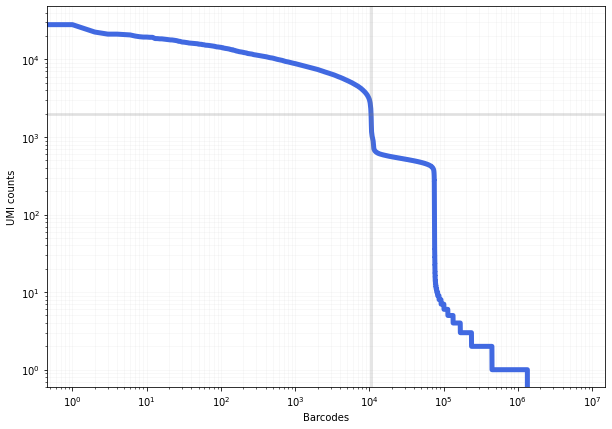

In [216]:
#Manually set UMI cutoff based on knee of plot
cutoff = 2000
knee = np.sort((np.array(dat.X.sum(axis=1))).flatten())[::-1]
cell_set = np.arange(len(knee))
num_cells = cell_set[knee > cutoff][::-1][0]

fig, ax = plt.subplots(figsize=(10, 7))


ax.loglog(cell_set, knee, linewidth=5, color="#4169e1")
ax.axhline(y=cutoff, linewidth=3, color="grey", alpha = .2)


ax.axvline(x=num_cells, linewidth=3, color="grey", alpha = .2)

ax.set_xlabel("Barcodes")
ax.set_ylabel("UMI counts")

plt.grid(True, which="both", alpha = .1)
plt.show()

In [217]:
#Manually set gene cutoff (usually half of UMI cutoff)
sc.pp.filter_cells(dat, min_genes=1000)
sc.pp.filter_cells(dat, min_counts=knee[num_cells])
sc.pp.filter_genes(dat, min_cells=3)

In [218]:
dat

AnnData object with n_obs × n_vars = 10513 × 18056
    obs: 'n_genes', 'n_counts'
    var: 'gene_symbols', 'feature_types', 'n_cells'

In [221]:
raw_matrix = dat.X.todense()
scrub = scr.Scrublet(raw_matrix)
doublet_score, predicted_doublets = scrub.scrub_doublets()
real_cells = np.logical_not(predicted_doublets)
dat = dat[real_cells,:]

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.79
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.2%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 5.3%
Elapsed time: 10.7 seconds


In [222]:
AC_list = []
for item in dat.obs.index:
    try:
        AC_list.append(AC_dat[item].X.sum())
    except:
        AC_list.append(0)

In [223]:
MO_list = []
for item in dat.obs_names:
    MO_list.append(dat[item].X.sum())

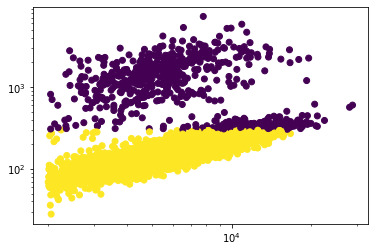

In [224]:
#plot the number of species1 counts vs species2 counts
thr = #set threshold based on plot
fin = []
for i in range(len(MO_list)):
    if AC_list[i] < thr:
        fin.append(1)
    else:
        fin.append(0)
plt.scatter(MO_list,AC_list,c = fin)
plt.yscale('log')
plt.xscale('log')

In [225]:
#keep cells with low species1 count high species2 count
dat_fin = dat[np.array(fin).astype(bool),:]

In [226]:
dat_fin

View of AnnData object with n_obs × n_vars = 9834 × 18056
    obs: 'n_genes', 'n_counts'
    var: 'gene_symbols', 'feature_types', 'n_cells'

In [188]:
dataframe = dat_fin

/scratch/miniconda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/scratch/miniconda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


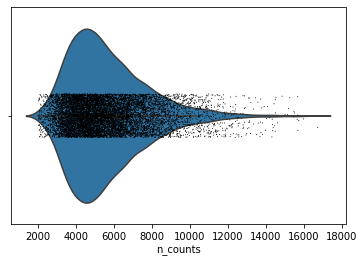

In [217]:
sns.violinplot(dataframe.obs['n_counts'])
sns.stripplot(dataframe.obs['n_counts'], color= "black", s = 1)
plt.savefig('MO/' + MO_dat_name.split('/')[1] + '_ncounts.png')

/scratch/miniconda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/scratch/miniconda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


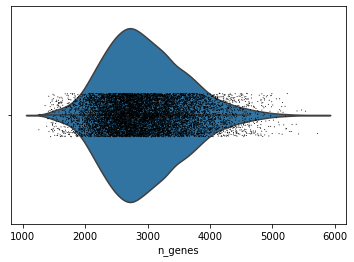

In [218]:
sns.violinplot(dataframe.obs['n_genes'])
sns.stripplot(dataframe.obs['n_genes'], color= "black", s = 1)
plt.savefig('MO/' + MO_dat_name.split('/')[1] + '_ngenes.png')

In [189]:
dataframe

View of AnnData object with n_obs × n_vars = 9834 × 18056
    obs: 'n_genes', 'n_counts'
    var: 'gene_symbols', 'feature_types', 'n_cells'

In [192]:
print(dataframe.X[:,1])

  (0, 0)	1.0
  (2, 0)	1.0
  (3, 0)	2.0
  (5, 0)	2.0
  (6, 0)	2.0
  (8, 0)	2.0
  (10, 0)	2.0
  (12, 0)	1.0
  (13, 0)	1.0
  (15, 0)	1.0
  (17, 0)	1.0
  (19, 0)	1.0
  (20, 0)	1.0
  (21, 0)	1.0
  (23, 0)	2.0
  (31, 0)	2.0
  (32, 0)	1.0
  (33, 0)	1.0
  (34, 0)	1.0
  (36, 0)	1.0
  (37, 0)	3.0
  (38, 0)	2.0
  (39, 0)	1.0
  (41, 0)	1.0
  (46, 0)	2.0
  :	:
  (9767, 0)	3.0
  (9768, 0)	1.0
  (9769, 0)	1.0
  (9771, 0)	1.0
  (9774, 0)	1.0
  (9775, 0)	3.0
  (9776, 0)	1.0
  (9778, 0)	1.0
  (9779, 0)	2.0
  (9781, 0)	1.0
  (9782, 0)	2.0
  (9784, 0)	1.0
  (9797, 0)	1.0
  (9798, 0)	4.0
  (9802, 0)	1.0
  (9806, 0)	1.0
  (9807, 0)	3.0
  (9809, 0)	1.0
  (9812, 0)	2.0
  (9816, 0)	1.0
  (9819, 0)	1.0
  (9822, 0)	1.0
  (9825, 0)	1.0
  (9827, 0)	2.0
  (9832, 0)	1.0


In [193]:
filename = 'MO/preprocessed_Run12_sample12_MO_soupx.h5ad'
print(filename)
dataframe.write(filename = filename)

MO/preprocessed_Run12_sample12_MO_soupx.h5ad


In [194]:
dataframe = sc.read_h5ad('MO/preprocessed_Run12_sample12_MO_soupx.h5ad')

In [163]:
sam=SAM(dataframe)
sam.preprocess_data() # log transforms and filters the data
sam.run() #run with default parameters

RUNNING SAM
Iteration: 0, Convergence: 1.0
Iteration: 1, Convergence: 0.820628676132878
Iteration: 2, Convergence: 0.016168210375050097
Computing the UMAP embedding...
Elapsed time: 11.875360488891602 seconds


In [147]:
sam1.clustering(param = 1)

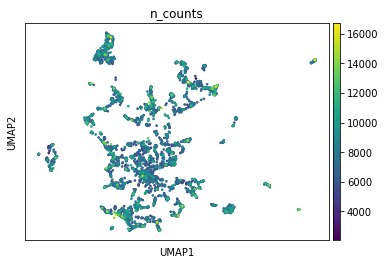

In [148]:
sc.pl.umap(sam1.adata, color = 'n_counts', save = '/Run12_sample12_hc_umap.png')

In [51]:
sam.adata.obs['leiden_clusters'].to_csv('Run12_sample12_leiden_clusters.csv')